# **2. PCA Analysis**

Neste notebook iremos implementar o PCA para reduzir a dimensionalidade do espaço de features cujas amostras/isolados vivem.

## **2.1 Imports**

In [2]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [3]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from src.pca.plots import plot_cumulative_variance, plot_explained_variance_ratio, plot_pca_scatter

## **2.2 Load Data**

In [4]:
X = pd.read_parquet('../data/processed/X_genotypes.parquet').values
y = pd.read_csv('../data/processed/y_clades.csv').squeeze()

## **2.3 PCA**

### **2.3.1 PCA Full**

Nesta etapa "fitamos" o PCA sobre a matriz de genótipos em busca de determinar quantos autovetores da matriz de covariância são necessários para reter 95% ou mais da variância total. Essa abordagem permite estabelecer a dimensionalidade intrínsica do "dataset", isto é, quantas dimensões são realmente informativas.

In [5]:
pca_full = PCA(random_state=42)
pca_full.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

(<Figure size 720x480 with 1 Axes>,
 <Axes: xlabel='Number of components', ylabel='Cumulative Explained Variance'>)

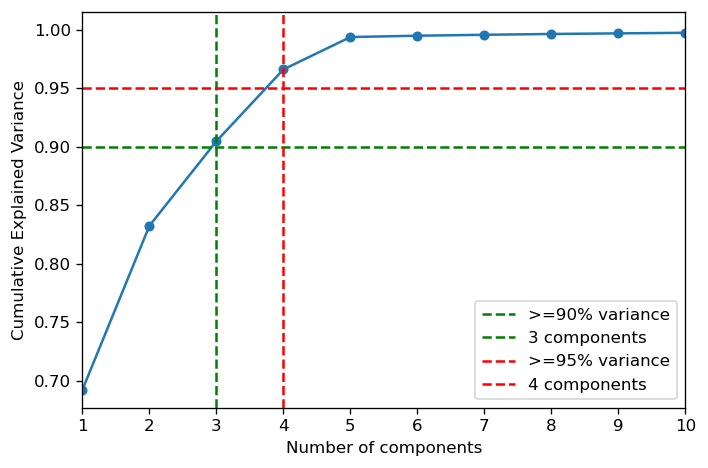

In [6]:
plot_cumulative_variance(pca_full)

(<Figure size 720x480 with 1 Axes>,
 <Axes: xlabel='Principal Component', ylabel='Explained Variance Ratio'>)

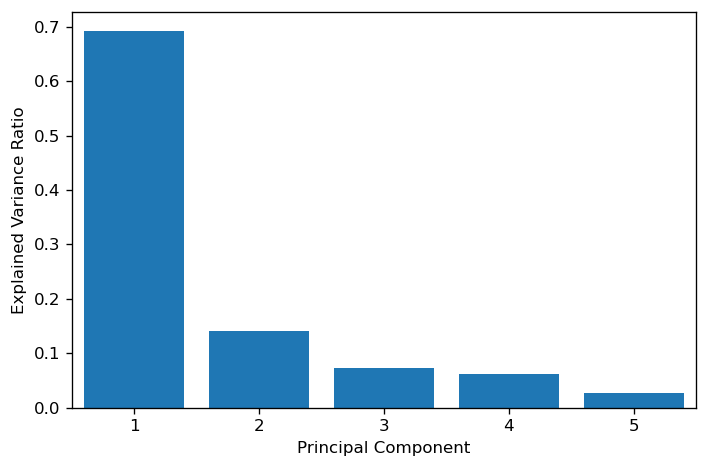

In [7]:
plot_explained_variance_ratio(pca_full)

É possível notar que a variância explicada pelas componentes 3 e 4 são bem próximas, de modo que não há motivos claros para manter apenas uma e desconsiderar a outra. Além disso, 4 componentes se aproximam de uma variância explicada acumulada de 100%.

### **2.3.2 PCA for a Fixed Number of Components**

Uma vez determinado o número necessário de componentes PCA, estabelecemos o "fit" fornecendo a priori esse número:

In [8]:
pca = PCA(n_components=4, random_state=42)

Z = pca.fit_transform(X)

Cada coluna do tensor **Z** representa uma componente PCA; ou seja, cada amostra vive em um espaço 4-dimensional, cuja base é dada pelas componentes PCA. Podemos organizar esses vetores em um DataFrame:

In [9]:
X_pca = pd.DataFrame(Z, columns=[f'PC{i+1}' for i in range(Z.shape[1])])

X_pca

,PC1,PC2,PC3,PC4
0,11.417779,121.496845,-126.584428,-30.460188
1,-47.115832,-18.633270,-0.482775,-0.018571
2,279.217758,-21.946535,5.404063,-11.551969
3,-47.129709,-18.670981,-0.479550,-0.015745
4,-47.150249,-18.707917,-0.485643,-0.022390
...,...,...,...,...
148,-47.122029,-18.645347,-0.484158,-0.013572
149,-47.150277,-18.707971,-0.485646,-0.022391
150,279.131299,-21.915341,5.378629,-11.488859
151,-47.132511,-18.666146,-0.469839,-0.013380


## **2.4 Scatter Plot: Samples on PCA Space**

### **2.4.1 (2D) Plots**

(<Figure size 1800x720 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 vs PC2'}, xlabel='PC1', ylabel='PC2'>,
        <Axes: title={'center': 'PC1 vs PC3'}, xlabel='PC1', ylabel='PC3'>,
        <Axes: title={'center': 'PC1 vs PC4'}, xlabel='PC1', ylabel='PC4'>],
       dtype=object))

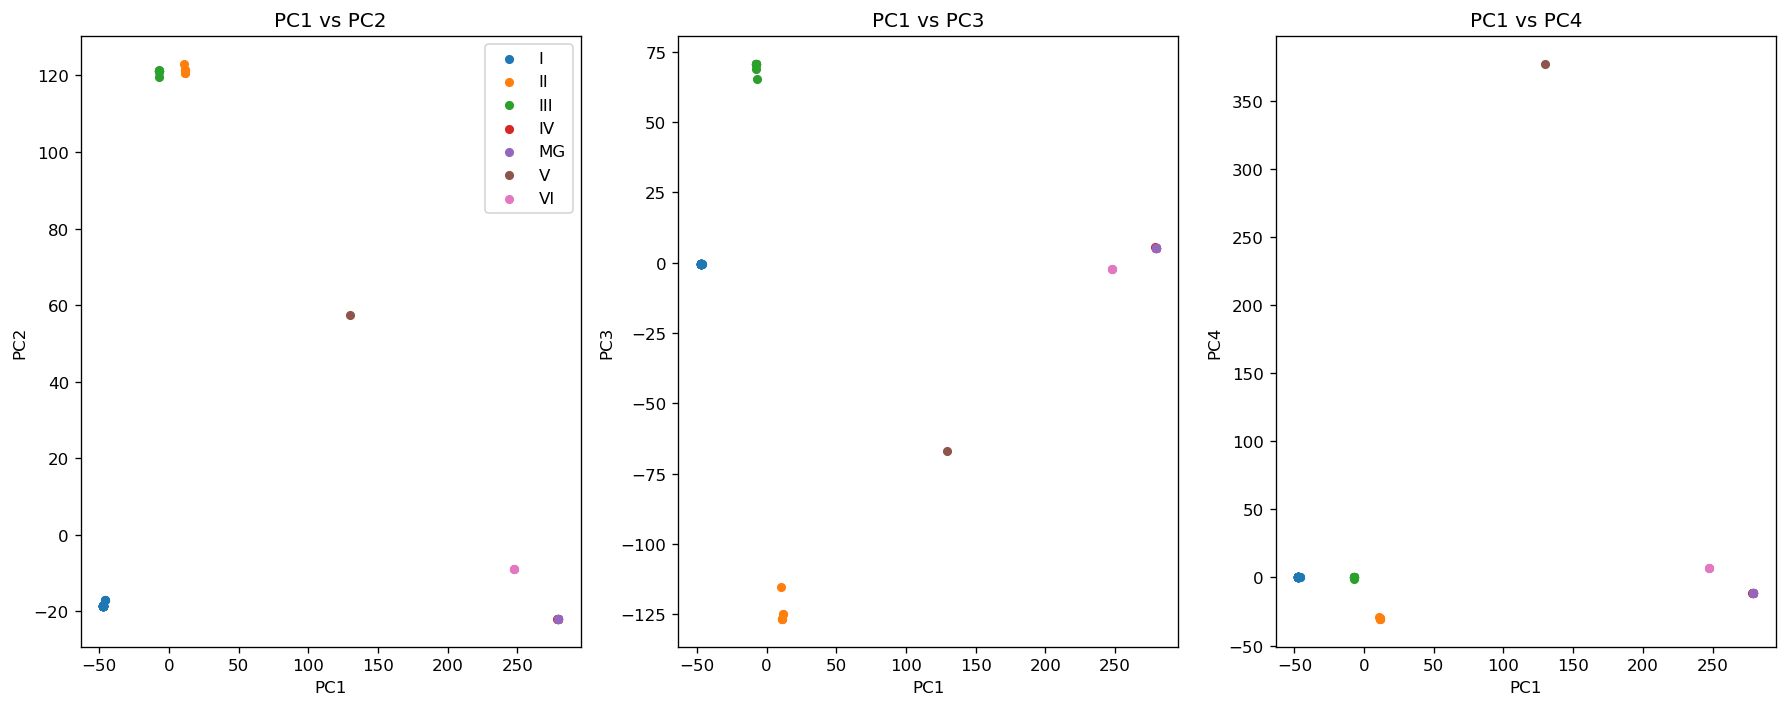

In [10]:
plot_pca_scatter(X_pca, y)

Usando a base de componentes PCA, fica evidente que as amostras tendem a se agrupar espacialmente, de acordo com cada clado. Está é a primeira evidência de que há similaridade compartilhada entre SNP's das amostras, permitindo o agrupamento em "famílias" biológicas similares. 

### **2.4.2 (3D) Plots**

In [11]:
fig = px.scatter_3d(X_pca, x=X_pca['PC1'], y=X_pca['PC2'], z=X_pca['PC3'], color=y)
fig.show()

### **2.5 PCA Loadings**

Os "loadings" estabelecem a contribuição de cada feature ao longo de cada eixo PCA de separação.

In [58]:
snp_info = pd.read_csv('../data/processed/snp_info.csv')
transition_info = pd.read_csv('../data/processed/transition_info.csv')

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
loadings['chrom'] = snp_info['chrom'].values
loadings['pos'] = snp_info['pos'].values

# Top 20 SNPs com maior peso absoluto em PC1
top_snps_pc1 = loadings.reindex(loadings['PC1'].abs().nlargest(20).index)
top_idx = loadings['PC1'].abs().nlargest(20).index

- **SNPs mais discriminantes na separação promovida pela primeira componente PCA:**

In [59]:
top_snps_pc1

,PC1,PC2,PC3,PC4,chrom,pos
89819,0.005965,-0.002132,0.000874,-0.002106,nc_072813.1,1105307
101986,0.004310,-0.001097,-0.000214,0.003739,nc_072813.1,1630794
102499,0.003836,0.007194,0.009882,-0.000823,nc_072813.1,1651438
109205,0.003730,-0.000676,-0.000713,0.006545,nc_072813.1,1881606
124520,0.003730,-0.000676,-0.000713,0.006545,nc_072813.1,2553568
240826,0.003730,-0.000676,-0.000713,0.006545,nc_072817.1,718285
241513,0.003730,-0.000676,-0.000713,0.006545,nc_072817.1,742400
130,0.003654,-0.000843,-0.000336,0.004044,nc_072812.1,14577
485,0.003654,-0.000843,-0.000336,0.004044,nc_072812.1,24296
8249,0.003654,-0.000843,-0.000336,0.004044,nc_072812.1,367061


- **SNP's mais discriminantes e suas substituições:**

In [60]:
top_snps_full = pd.concat(
    [transition_info.loc[top_idx, ['ref', 'alt']], loadings.loc[top_idx]],
    axis=1
)[['ref', 'alt', 'chrom', 'pos', 'PC1', 'PC2', 'PC3', 'PC4']]

top_snps_full

,ref,alt,chrom,pos,PC1,PC2,PC3,PC4
89819,g,"c,a",nc_072813.1,1105307,0.005965,-0.002132,0.000874,-0.002106
101986,a,"t,c",nc_072813.1,1630794,0.004310,-0.001097,-0.000214,0.003739
102499,t,"t,a,c,g",nc_072813.1,1651438,0.003836,0.007194,0.009882,-0.000823
109205,c,"t,g,a",nc_072813.1,1881606,0.003730,-0.000676,-0.000713,0.006545
124520,c,"g,t,a",nc_072813.1,2553568,0.003730,-0.000676,-0.000713,0.006545
240826,a,"t,c,g",nc_072817.1,718285,0.003730,-0.000676,-0.000713,0.006545
241513,a,"t,c,g",nc_072817.1,742400,0.003730,-0.000676,-0.000713,0.006545
130,t,"g,a",nc_072812.1,14577,0.003654,-0.000843,-0.000336,0.004044
485,a,"g,c",nc_072812.1,24296,0.003654,-0.000843,-0.000336,0.004044
8249,t,"a,g",nc_072812.1,367061,0.003654,-0.000843,-0.000336,0.004044


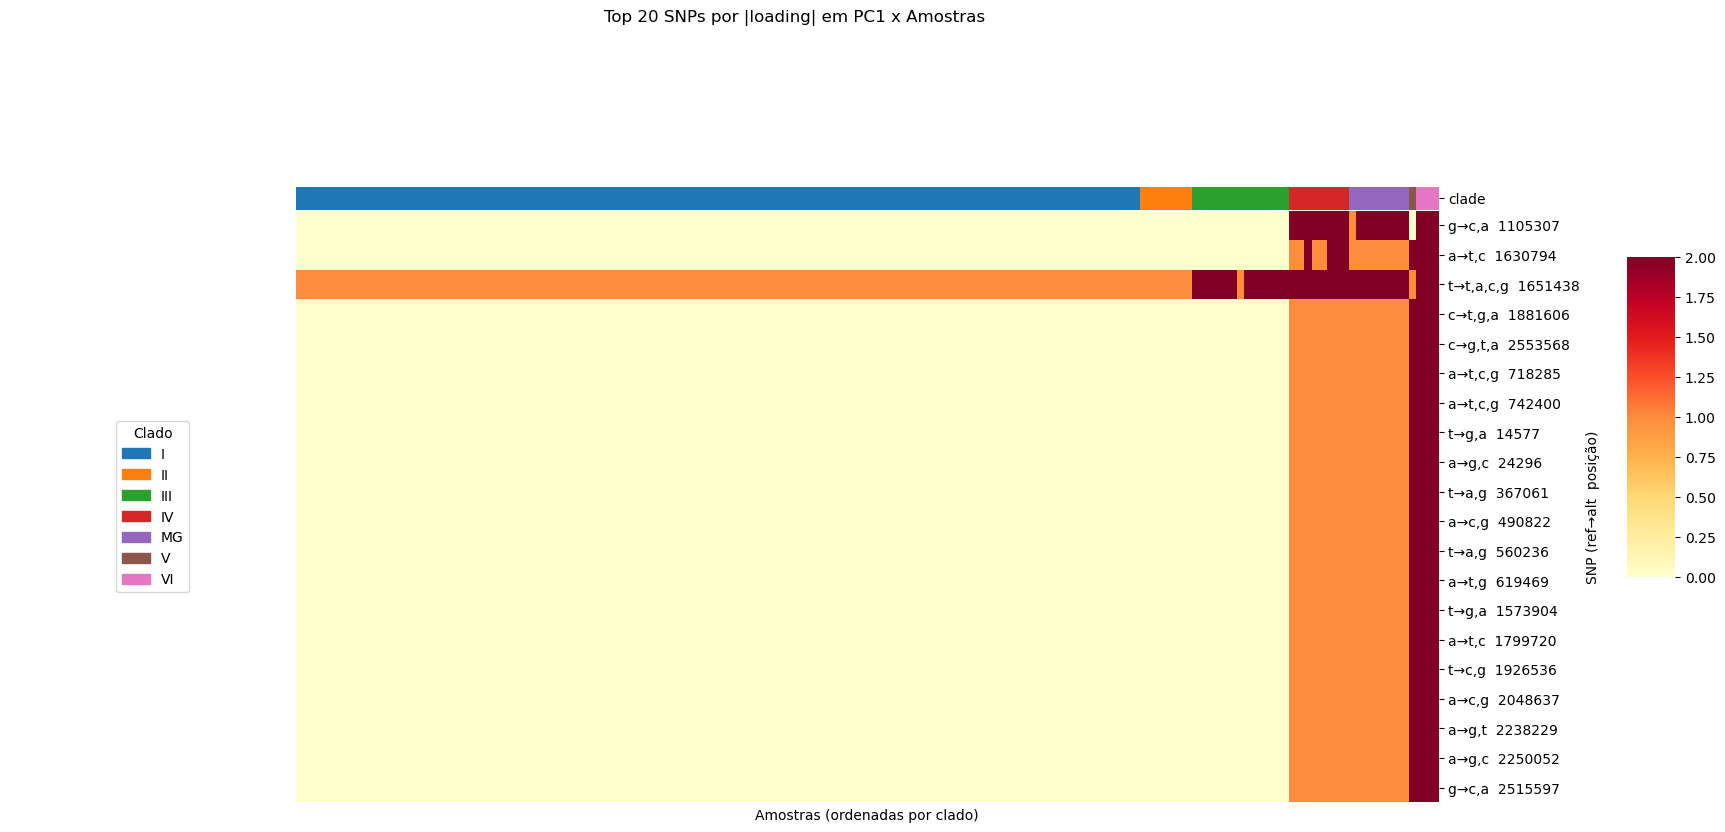

In [61]:
import seaborn as sns

col_labels = [
    f"{row['ref']}→{row['alt']}  {row['pos']}"
    for _, row in top_snps_full.iterrows()
]
X_top = pd.DataFrame(X[:, top_idx], columns=col_labels)

# Organiza amostras por clado
sort_order = y.sort_values().index
X_top_sorted = X_top.iloc[sort_order].reset_index(drop=True)
clades_sorted = y.iloc[sort_order].reset_index(drop=True)

# Column colors per clade
palette = sns.color_palette('tab10', n_colors=y.nunique())
clade_lut = dict(zip(sorted(y.unique()), palette))
col_colors = clades_sorted.map(clade_lut)

g = sns.clustermap(
    X_top_sorted.T,
    row_cluster=False,
    col_cluster=False,
    col_colors=col_colors,
    cmap='YlOrRd',
    vmin=0, vmax=2,
    figsize=(16, 8),
    xticklabels=False,
    cbar_pos=(1.02, 0.3, 0.03, 0.4),
)
g.ax_heatmap.set_xlabel('Amostras (ordenadas por clado)')
g.ax_heatmap.set_ylabel('SNP (ref→alt  posição)')
g.figure.suptitle('Top 20 SNPs por |loading| em PC1 x Amostras', y=1.01)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=cl) for cl, c in clade_lut.items()]
g.ax_row_dendrogram.legend(handles=handles, title='Clado', loc='center', ncol=1)

plt.show()

No heatmap acima, a leitura de uma coluna permite a seguinte pergunta: **para uma amostra (clado identificado pela cor do topo), em cada um dos 20 SNPs mais discriminantes de PC1, qual é o estado genotípico?**

## **2.6 Conclusions**

O PCA com 4 componentes retém 97% da variância total dos dados de SNPs. Os scatter plots (PC1 vs PC2, PC1 vs PC3, PC1 vs PC4) revelam que isolados de um mesmo clado se agrupam no espaço reduzido, fornecendo a primeira evidência não-supervisionada de que a classificação em clados possui base genômica real. Cada componente principal contribui para a separação de clados distintos, e a combinação de múltiplas projeções (PC1 vs PC2, PC1 vs PC3, PC1 vs PC4) é necessária para visualizar a separação completa entre os 6 clados, nenhuma projeção bidimensional isolada resolve todos simultaneamente. Os loadings do PCA identificam as posições de SNPs específicas (cromossomo e posição) que mais contribuem para cada eixo de separação. Esses resultados motivam a aplicação de K-Means para testar formalmente se os dados sustentam a existência de 6 grupos distintos.

Além disso, o gráfico 3D aponta para o fato das amostras de **MG** estarem consistentemente sobrepostas àquelas do clado IV. Investigaremos com K-means e algoritmos supervisionados se este é o caso.
